In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Cargar datos

In [3]:
data_path = 'm5-forecasting-accuracy/'

In [4]:
sales = pd.read_csv(f'{data_path}sales_train_evaluation.csv')
calendar = pd.read_csv(f'{data_path}calendar.csv')

In [5]:
sales

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


# Pre filtrado

In [6]:
# Filtramos solo la cateogira foods y una única tienda "CA_1"
foods = sales[(sales['cat_id'] == 'FOODS')&(sales['store_id'] =='CA_1')].copy()

In [7]:
# Obtener solo las columnas de ventas diarias
d_cols = [c for c in foods.columns if c.startswith('d_')]
sales_data = foods[d_cols].values

In [8]:
# Listas para guardar los resultados
adi_list = []
cv2_list = []

print("Calculando ADI y CV^2...")
for i in range(sales_data.shape[0]):
    ts = sales_data[i]
    
    # 2. Eliminar ceros iniciales (antes del lanzamiento del producto)
    if ts.max() == 0: # Si el producto nunca se vendió
        adi_list.append(np.nan)
        cv2_list.append(np.nan)
        continue
        
    first_sale_idx = (ts > 0).argmax() 
    ts_active = ts[first_sale_idx:] # Serie de tiempo real (activa)
    # Ventas estrictamente positivas
    non_zero_demand = ts_active[ts_active > 0]
    # 3. Calcular ADI (Total de periodos activos / Periodos con venta)
    adi = len(ts_active) / len(non_zero_demand)
    # 4. Calcular CV^2 (Varianza / Media al cuadrado de las ventas NO nulas)
    if len(non_zero_demand) > 1:
        cv2 = (np.std(non_zero_demand, ddof=1) / np.mean(non_zero_demand)) ** 2
    else:
        cv2 = np.nan
    adi_list.append(adi)
    cv2_list.append(cv2)
foods['ADI'] = adi_list
foods['CV2'] = cv2_list

Calculando ADI y CV^2...


In [9]:
# Eliminar series sin datos suficientes
foods = foods.dropna(subset=['ADI', 'CV2'])

# 5. Clasificar la demanda (Umbrales de Syntetos et al.)
def categorize_demand(row):
    if row['ADI'] < 1.32 and row['CV2'] < 0.49:
        return 'Smooth'
    elif row['ADI'] >= 1.32 and row['CV2'] < 0.49:
        return 'Intermittent'
    elif row['ADI'] < 1.32 and row['CV2'] >= 0.49:
        return 'Erratic'
    else:
        return 'Lumpy'

foods['Demand_Type'] = foods.apply(categorize_demand, axis=1)

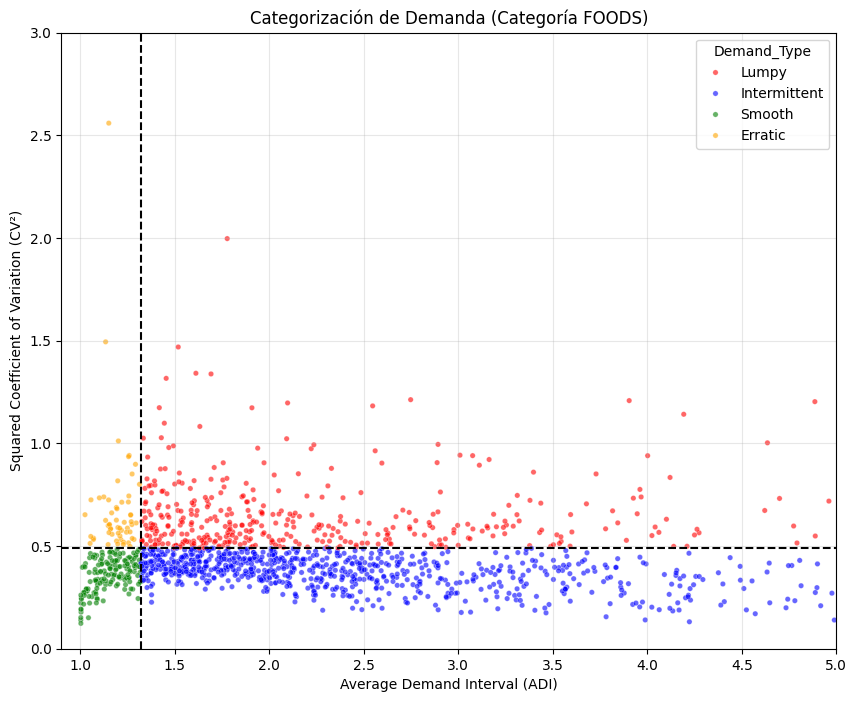

In [10]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=foods, x='ADI', y='CV2', hue='Demand_Type', 
                palette={'Smooth': 'green', 'Intermittent': 'blue', 
                         'Erratic': 'orange', 'Lumpy': 'red'}, 
                alpha=0.6, s=15)

# Añadir las líneas divisorias de los cuadrantes
plt.axvline(x=1.32, color='black', linestyle='--')
plt.axhline(y=0.49, color='black', linestyle='--')

# Ajustar límites para mejor visualización (hay outliers muy extremos)
plt.xlim(0.9, 5)
plt.ylim(0, 3)

plt.title('Categorización de Demanda (Categoría FOODS)')
plt.xlabel('Average Demand Interval (ADI)')
plt.ylabel('Squared Coefficient of Variation (CV²)')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
smooth_products = foods[foods['Demand_Type'] == 'Smooth']
n_sample = 10
sample_smooth = smooth_products.sample(n=n_sample, random_state=40)

In [12]:
sample_smooth

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941,ADI,CV2,Demand_Type
2693,FOODS_3_469_CA_1_evaluation,FOODS_3_469,FOODS_3,FOODS,CA_1,CA,1,5,4,5,...,5,1,7,1,10,7,9,1.158806,0.389018,Smooth
2770,FOODS_3_546_CA_1_evaluation,FOODS_3_546,FOODS_3,FOODS,CA_1,CA,5,0,0,0,...,2,5,6,0,0,2,11,1.118088,0.456660,Smooth
2820,FOODS_3_596_CA_1_evaluation,FOODS_3_596,FOODS_3,FOODS,CA_1,CA,1,1,1,6,...,6,1,3,0,2,3,1,1.262029,0.326410,Smooth
2794,FOODS_3_570_CA_1_evaluation,FOODS_3_570,FOODS_3,FOODS,CA_1,CA,0,0,0,0,...,4,6,3,7,15,13,5,1.083444,0.266381,Smooth
2682,FOODS_3_458_CA_1_evaluation,FOODS_3_458,FOODS_3,FOODS,CA_1,CA,10,5,8,2,...,4,0,9,3,5,6,9,1.091676,0.370537,Smooth
2961,FOODS_3_739_CA_1_evaluation,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,0,0,0,0,...,6,13,13,7,7,8,16,1.091659,0.311538,Smooth
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,107,182,47,47,...,38,42,39,51,69,67,64,1.318614,0.327244,Smooth
2393,FOODS_3_169_CA_1_evaluation,FOODS_3_169,FOODS_3,FOODS,CA_1,CA,0,0,0,0,...,4,0,3,2,2,2,4,1.291103,0.395033,Smooth
2946,FOODS_3_723_CA_1_evaluation,FOODS_3_723,FOODS_3,FOODS,CA_1,CA,17,16,8,13,...,4,5,14,15,11,6,17,1.315041,0.398960,Smooth
2593,FOODS_3_369_CA_1_evaluation,FOODS_3_369,FOODS_3,FOODS,CA_1,CA,0,0,0,3,...,0,0,1,2,2,1,4,1.293725,0.410795,Smooth


# EDA

In [13]:
# 1. Definir qué columnas vamos a mantener fijas y cuáles vamos a "derretir" (melt)
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
# Tomamos todas las columnas que empiezan con 'd_' (d_1, d_2, etc.)
d_cols = [c for c in sample_smooth.columns if c.startswith('d_')]

# 2. Ejecutar el melt
melted_smooth = pd.melt(
    sample_smooth, 
    id_vars=id_vars, 
    value_vars=d_cols, 
    var_name='d',       # El nombre de la nueva columna que tendrá d_1, d_2...
    value_name='sales'  # El nombre de la nueva columna con las ventas
)

In [14]:
# 3. Cruzar con el calendario para obtener las fechas reales
melted_smooth = pd.merge(
    melted_smooth, 
    calendar[['d', 'date']], # Solo traemos la llave 'd' y la fecha real 'date'
    on='d', 
    how='left'
)

# Convertir la columna 'date' a formato datetime de pandas (clave para graficar bien)
melted_smooth['date'] = pd.to_datetime(melted_smooth['date'])
# Ordenar cronológicamente (siempre es una buena práctica en series de tiempo)
melted_smooth = melted_smooth.sort_values(['id', 'date']).reset_index(drop=True)

## Series de tiempo iniciales

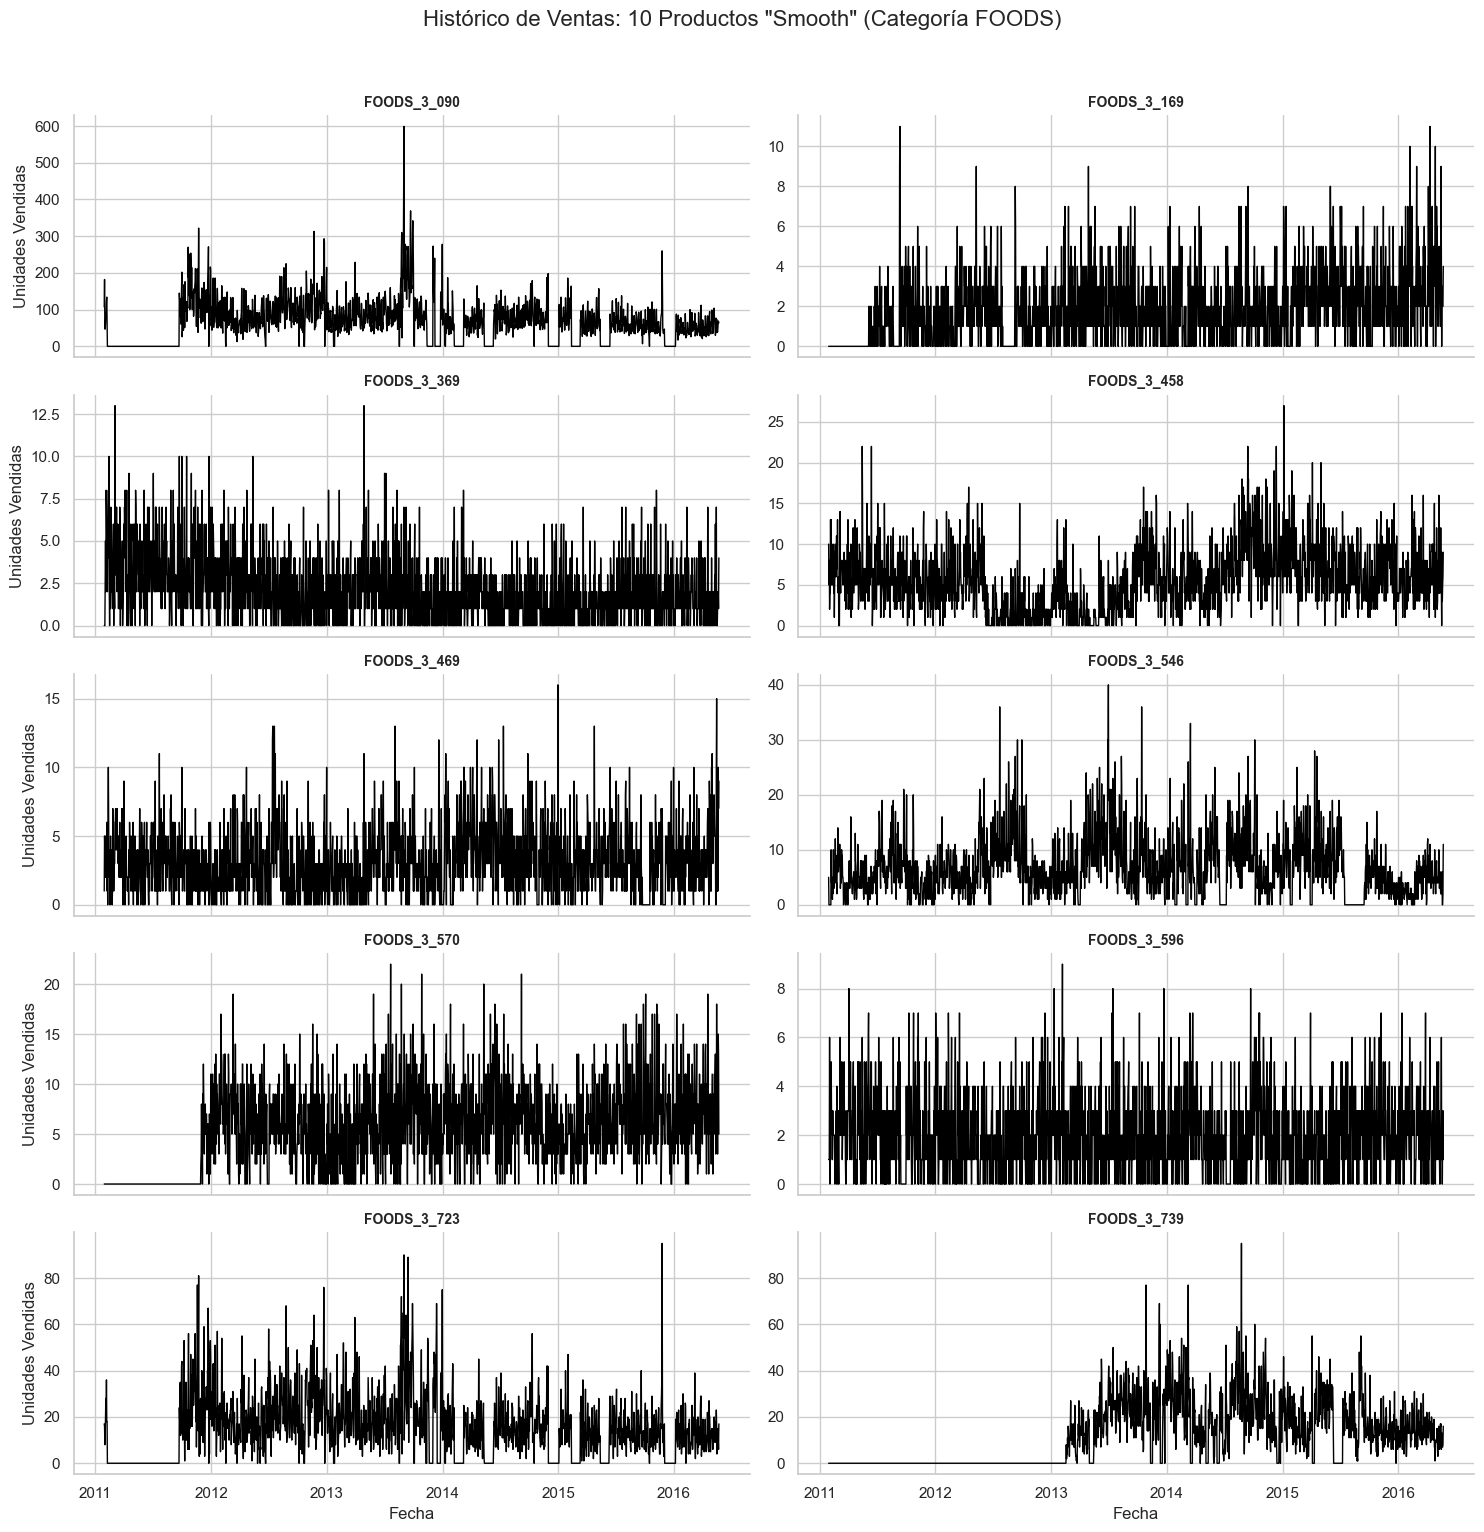

In [15]:
# Configuramos el estilo del gráfico
sns.set_theme(style="whitegrid")

#Creamos la cuadrícula: 2 columnas, 5 filas
g = sns.FacetGrid(
    melted_smooth, 
    col="item_id", 
    col_wrap=2, 
    height=3, 
    aspect=2.5, 
    sharey=False
)

# Mapeamos el lineplot (cambiamos el color a 'black')
g.map(sns.lineplot, "date", "sales", linewidth=1, color="black")

# Ajustes de títulos y etiquetas generales
g.set_axis_labels("Fecha", "Unidades Vendidas")
g.set_titles(col_template="{col_name}", size=10, weight='bold')
plt.suptitle('Histórico de Ventas: 10 Productos "Smooth" (Categoría FOODS)', y=1.02, fontsize=16)

# Iteramos sobre cada subgráfico para ajustar el eje X
for ax in g.axes.flat:
    # 1. Limitar a un máximo de 5 etiquetas en el eje X
    # ax.xaxis.set_major_locator(mdates.MaxNLocator(nbins=5))
    # 2. Formato explícito de Año-Mes (ej. '2012-08')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # 3. Ajuste de rotación (al ser solo 5, a 0 grados suele verse muy limpio, 
    # pero puedes cambiarlo a 45 si ves que se solapan)
    for label in ax.get_xticklabels():
        label.set_rotation(0) 

plt.tight_layout()
plt.show()

## Series de tiempo filtradas

In [16]:
# Agrupamos por 'id' y hacemos una suma acumulada de las ventas.
# Los días previos a la primera venta sumarán 0.
# En el momento en que hay una venta (ej: 2), la suma acumulada pasa a ser > 0 para siempre.
mask_active_life = melted_smooth.groupby('id')['sales'].cumsum() > 0

# Filtramos el dataframe conservando solo la "vida activa" del producto
melted_clean = melted_smooth[mask_active_life].copy()

In [17]:
# 1. Definimos una función que actuará sobre cada producto individualmente
def remove_discontinued_periods(group_df, gap_threshold=180):
    """
    Recorta el inicio de la serie si hubo un gap de ventas mayor a 'gap_threshold' días.
    """
    # Asegurarnos de que el df está ordenado cronológicamente
    group_df = group_df.sort_values('date')
    # Aislar solo los días en que hubo ventas (sales > 0)
    sales_days = group_df[group_df['sales'] > 0].copy()
    if len(sales_days) <= 1:
        return group_df
    # Calcular cuántos días pasaron desde la última venta
    sales_days['gap_days'] = sales_days['date'].diff().dt.days
    # Identificar si existe algún gap mayor a nuestro umbral (ej. 180 días o medio año)
    big_gaps = sales_days[sales_days['gap_days'] >= gap_threshold]
    if not big_gaps.empty:
        # Si hubo baches gigantes, tomamos la fecha donde se rompió el ÚLTIMO gran gap
        # Esa será la nueva "fecha de relanzamiento"
        last_relaunch_date = big_gaps['date'].max()
        # Filtramos la serie para quedarnos solo con la historia post-relanzamiento
        return group_df[group_df['date'] >= last_relaunch_date]
    # Si no hubo grandes gaps, devolvemos la serie tal cual
    return group_df

In [18]:
# 2. Aplicamos la función agrupando por producto ('id')
# group_keys=False evita que Pandas cree un multi-índice innecesario
melted_clean = melted_clean.groupby('id', group_keys=False).apply(
    lambda df: remove_discontinued_periods(df, gap_threshold=180) 
)

In [19]:
melted_clean

,item_id,dept_id,cat_id,store_id,state_id,d,sales,date
237,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_238,145,2011-09-23
238,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_239,126,2011-09-24
239,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_240,100,2011-09-25
240,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_241,106,2011-09-26
241,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_242,80,2011-09-27
...,...,...,...,...,...,...,...,...
19405,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1937,13,2016-05-18
19406,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1938,7,2016-05-19
19407,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1939,7,2016-05-20
19408,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1940,8,2016-05-21


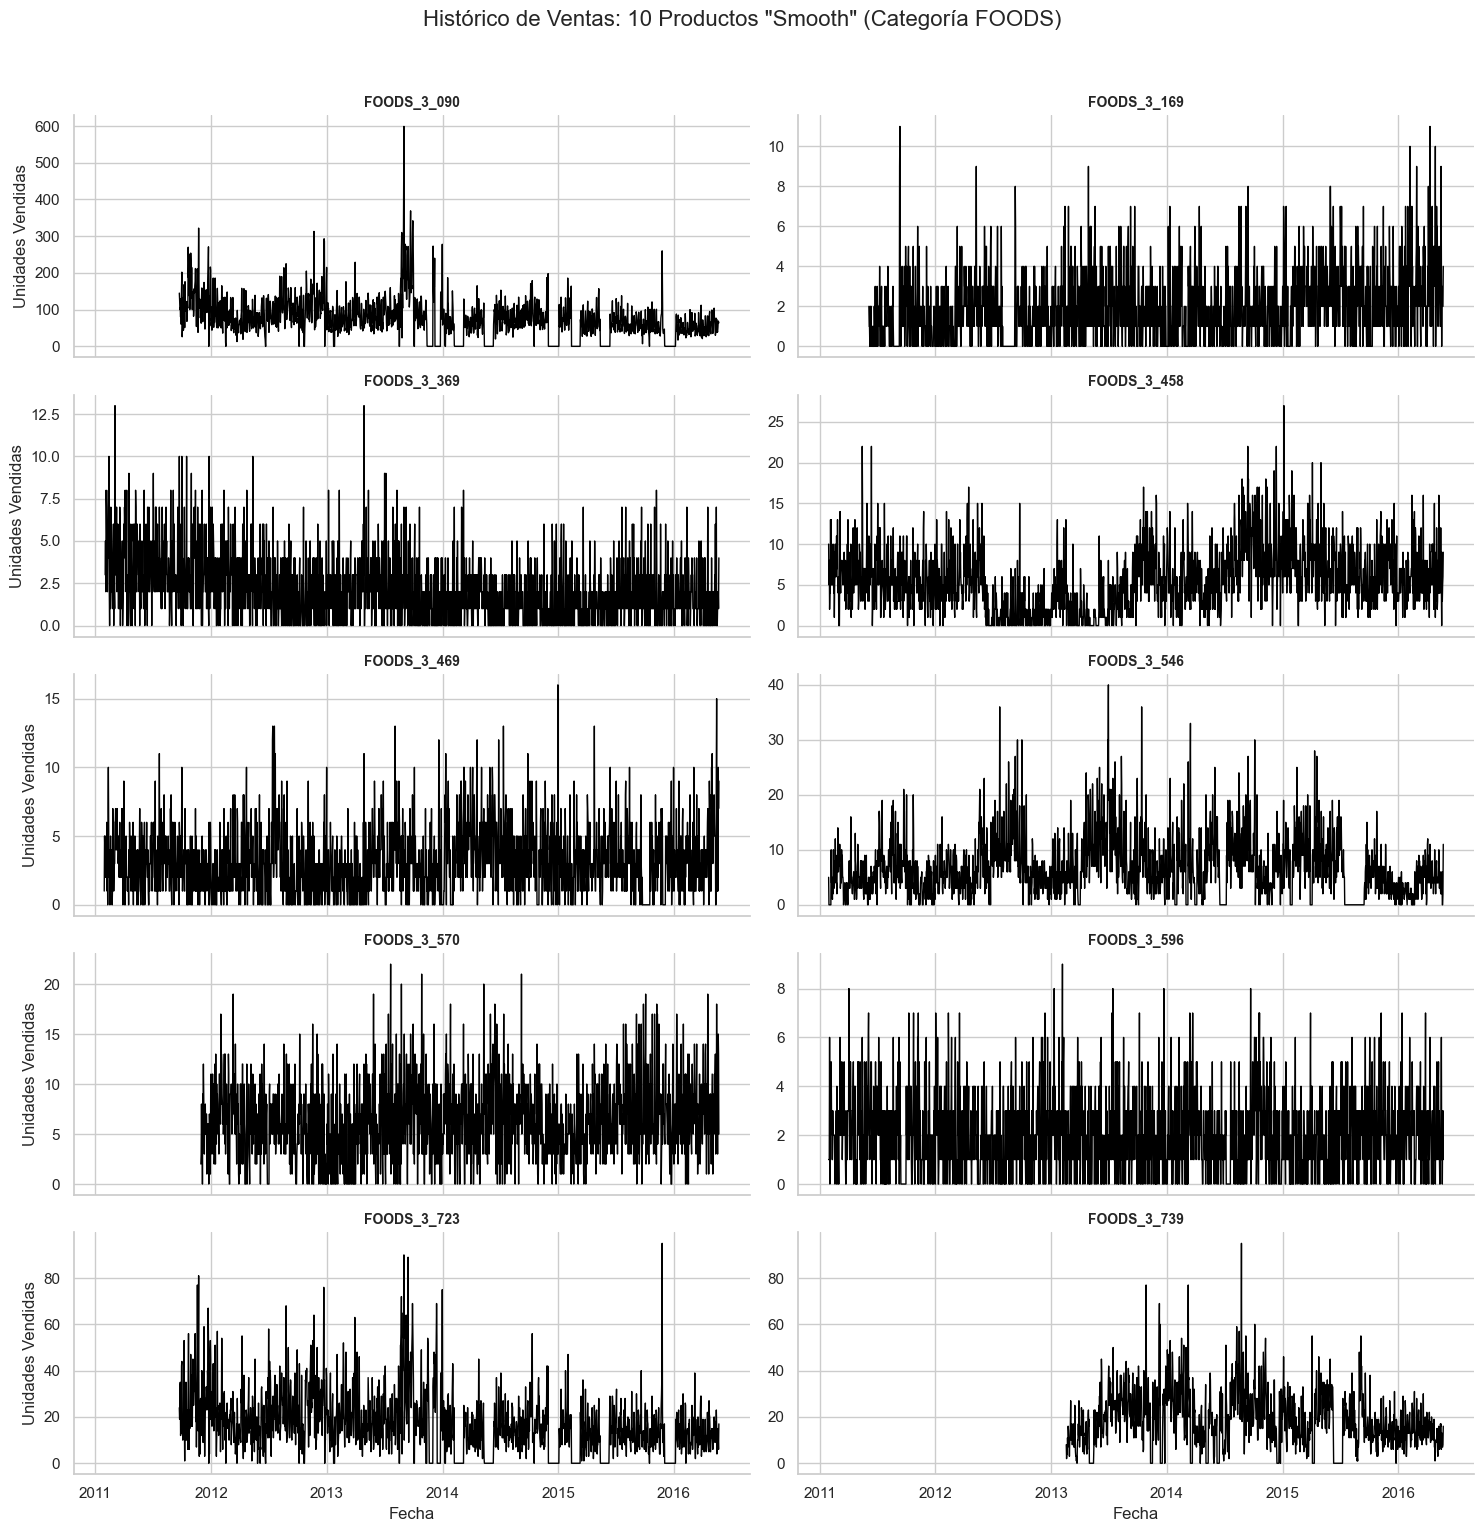

In [20]:
# Configuramos el estilo del gráfico
sns.set_theme(style="whitegrid")
#Creamos la cuadrícula: 2 columnas, 5 filas
g = sns.FacetGrid(
    melted_clean, 
    col="item_id", 
    col_wrap=2, 
    height=3, 
    aspect=2.5, 
    sharey=False
)
# Mapeamos el lineplot (cambiamos el color a 'black')
g.map(sns.lineplot, "date", "sales", linewidth=1, color="black")
# Ajustes de títulos y etiquetas generales
g.set_axis_labels("Fecha", "Unidades Vendidas")
g.set_titles(col_template="{col_name}", size=10, weight='bold')
plt.suptitle('Histórico de Ventas: 10 Productos "Smooth" (Categoría FOODS)', y=1.02, fontsize=16)

# Iteramos sobre cada subgráfico para ajustar el eje X
for ax in g.axes.flat:
    # 1. Limitar a un máximo de 5 etiquetas en el eje X
    # ax.xaxis.set_major_locator(mdates.MaxNLocator(nbins=5))
    # 2. Formato explícito de Año-Mes (ej. '2012-08')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # 3. Ajuste de rotación (al ser solo 5, a 0 grados suele verse muy limpio, 
    # pero puedes cambiarlo a 45 si ves que se solapan)
    for label in ax.get_xticklabels():
        label.set_rotation(0) 

plt.tight_layout()
plt.show()

# Separar en train/test

In [21]:
# 1. Definir la cantidad de días para test (8 semanas = 56 días)
test_days = 56
# 2. Encontrar la última fecha disponible en nuestros datos
max_date = melted_clean['date'].max()
# 3. Calcular la fecha de corte exacta
# Si restamos 56 días exactos, todo lo que sea MAYOR a ese corte serán nuestros 56 días de test.
cutoff_date = max_date - pd.Timedelta(days=test_days)

In [22]:
# 4. Dividir el dataset en Train y Test
train_df = melted_clean[melted_clean['date'] <= cutoff_date].copy()
test_df  = melted_clean[melted_clean['date'] > cutoff_date].copy()

# Baseline

In [36]:
# 1. Creamos una copia del Test para no alterar el original
baseline_df = test_df.copy()
# 2. Definimos el rezago (52 semanas exactas para hacer coincidir el día de la semana)
shift_days = 364 
# 3. Calculamos la fecha equivalente del año pasado para cada día de nuestro Test
baseline_df['lookup_date'] = baseline_df['date'] - pd.Timedelta(days=shift_days)
# 4. Preparamos los datos históricos (Train) para hacer el cruce
# Solo necesitamos el 'id', la fecha (que renombramos) y la venta (nuestra predicción)
history_for_lookup = train_df[['item_id', 'date', 'sales']].rename(
    columns={'date': 'lookup_date', 'sales': 'pred_snaive_anual'}
)
# 5. Cruzamos la información: Para cada día de Test, buscamos la venta de su 'lookup_date'
print("Calculando el baseline anual...")
baseline_df = pd.merge(baseline_df, history_for_lookup, on=['item_id', 'lookup_date'], how='left')
# 6. Manejo de nulos (Edge case)
# ¿Qué pasa si hace exactamente 364 días el producto no existía o estaba en un bache?
# Esas filas quedarán como NaN. Lo más conservador en un Naïve es imputar con 0 
# (asumiendo que no hubo venta) o con la media histórica. Usaremos 0.
baseline_df['pred_snaive_anual'] = baseline_df['pred_snaive_anual'].fillna(0)

# Demos un vistazo a los resultados para el primer producto
primer_id = baseline_df['item_id'].unique()[0]
muestra_resultados = baseline_df[baseline_df['item_id'] == primer_id][['item_id', 'date', 'sales', 'pred_snaive_anual']].head()
print("\nMuestra de las primeras 5 predicciones del primer producto:")
print(muestra_resultados)

Calculando el baseline anual...

Muestra de las primeras 5 predicciones del primer producto:
       item_id       date  sales  pred_snaive_anual
0  FOODS_3_090 2016-03-28     25                 45
1  FOODS_3_090 2016-03-29     47                 29
2  FOODS_3_090 2016-03-30     23                 40
3  FOODS_3_090 2016-03-31     21                 28
4  FOODS_3_090 2016-04-01     72                 94


## Metricas MAE Y RMSE

In [37]:
# 1. Calcular el error crudo (diferencia entre venta real y predicción)
baseline_df['error'] = baseline_df['sales'] - baseline_df['pred_snaive_anual']
# 2. Calcular el error absoluto (para el MAE) y el error al cuadrado (para el RMSE)
baseline_df['abs_error'] = baseline_df['error'].abs()
baseline_df['sq_error'] = baseline_df['error'] ** 2
# 3. Agrupar por producto ('id') y calcular los promedios
metrics_per_id = baseline_df.groupby('item_id').agg(
    MAE=('abs_error', 'mean'),
    MSE=('sq_error', 'mean')
).reset_index()
# 4. Calcular la raíz cuadrada del MSE para obtener el RMSE
metrics_per_id['RMSE'] = np.sqrt(metrics_per_id['MSE'])
metrics_per_id = metrics_per_id.drop(columns=['MSE']) # Limpiamos la columna intermedia

print("--- Métricas de Error por Producto (Test de 8 semanas) ---")
print(metrics_per_id.round(2)) # Redondeamos a 2 decimales para mejor lectura

# 5. Calcular la métrica global sobre todo el conjunto de prueba
global_mae = baseline_df['abs_error'].mean()
global_rmse = np.sqrt(baseline_df['sq_error'].mean())

print("\n--- Métricas Globales (Baseline SNaïve Anual) ---")
print(f"Global MAE : {global_mae:.2f} unidades")
print(f"Global RMSE: {global_rmse:.2f} unidades")

--- Métricas de Error por Producto (Test de 8 semanas) ---
       item_id    MAE   RMSE
0  FOODS_3_090  26.93  33.83
1  FOODS_3_169   2.11   2.71
2  FOODS_3_369   1.62   2.10
3  FOODS_3_458   4.41   5.77
4  FOODS_3_469   2.95   3.67
5  FOODS_3_546   4.96   6.48
6  FOODS_3_570   3.02   4.07
7  FOODS_3_596   1.64   2.14
8  FOODS_3_723   6.62   8.53
9  FOODS_3_739  14.43  17.08

--- Métricas Globales (Baseline SNaïve Anual) ---
Global MAE : 6.87 unidades
Global RMSE: 12.77 unidades


# Modelos

## Sarima

In [38]:
import pmdarima as pm
import time
import warnings
# Ignoramos warnings de convergencia para que la consola no se ensucie
warnings.filterwarnings("ignore")

In [39]:
# DataFrame para ir guardando todas las predicciones de SARIMA
sarima_predictions = []

print("Entrenando modelos SARIMA (esto puede tomar un par de minutos)...")

# Iteramos sobre cada producto único en nuestro set de Train
productos = train_df['item_id'].unique()
for prod_id in productos:
    start_time = time.time()
    # 1. Aislar los datos de entrenamiento para este producto
    df_train_prod = train_df[train_df['item_id'] == prod_id].sort_values('date')
    y_train = df_train_prod['sales'].values
    # 2. Entrenar el modelo Auto-ARIMA
    # m=7 (estacionalidad semanal), stepwise=True (búsqueda rápida)
    modelo_sarima = pm.auto_arima(
        y_train,
        seasonal=True,
        m=7,                 # Ciclo estacional de 7 días
        d=None, D=None,      # Deja que el algoritmo decida si necesita diferenciación
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        start_P=0, start_Q=0,
        max_P=3, max_Q=3,
        trace=False,         # Cambia a True si quieres ver el proceso iterativo
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True        # Algoritmo de Hyndman-Khandakar para búsqueda eficiente
    )
    # 3. Predecir los próximos 56 días (Test)
    # auto_arima devuelve las predicciones como un array
    forecast = modelo_sarima.predict(n_periods=test_days)
    # 4. Guardar las predicciones junto con sus fechas
    # Obtenemos las fechas de test para este producto
    fechas_test = test_df[test_df['item_id'] == prod_id].sort_values('date')['date'].values
    for fecha, pred in zip(fechas_test, forecast):
        sarima_predictions.append({
            'item_id': prod_id,
            'date': fecha,
            'pred_sarima': max(0, pred) # Forzamos a no tener ventas negativas
        })
        
    elapsed = time.time() - start_time
    print(f"[{prod_id}] Optimizado como {modelo_sarima.order}x{modelo_sarima.seasonal_order} - Tiempo: {elapsed:.1f}s")

Entrenando modelos SARIMA (esto puede tomar un par de minutos)...
[FOODS_3_090] Optimizado como (1, 1, 1)x(0, 0, 3, 7) - Tiempo: 77.3s
[FOODS_3_169] Optimizado como (1, 1, 1)x(2, 0, 1, 7) - Tiempo: 84.3s
[FOODS_3_369] Optimizado como (2, 1, 1)x(1, 0, 3, 7) - Tiempo: 142.0s
[FOODS_3_458] Optimizado como (1, 1, 1)x(0, 0, 3, 7) - Tiempo: 70.9s
[FOODS_3_469] Optimizado como (1, 1, 1)x(0, 0, 3, 7) - Tiempo: 77.0s
[FOODS_3_546] Optimizado como (2, 1, 1)x(1, 0, 3, 7) - Tiempo: 146.8s
[FOODS_3_570] Optimizado como (0, 1, 2)x(0, 0, 3, 7) - Tiempo: 96.0s
[FOODS_3_596] Optimizado como (2, 0, 2)x(3, 0, 0, 7) - Tiempo: 152.4s
[FOODS_3_723] Optimizado como (1, 1, 1)x(0, 0, 3, 7) - Tiempo: 84.1s
[FOODS_3_739] Optimizado como (2, 1, 1)x(2, 0, 1, 7) - Tiempo: 108.3s


In [40]:
# 5. Convertir la lista de resultados a DataFrame
df_sarima_results = pd.DataFrame(sarima_predictions)

# 6. Cruzar con nuestro dataframe del Baseline para tener todo junto
resultados_finales = pd.merge(baseline_df, df_sarima_results, on=['item_id', 'date'], how='left')

In [53]:
resultados_finales

,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,lookup_date,pred_snaive_anual,error,abs_error,sq_error,pred_sarima,error_sarima,abs_error_sarima,sq_error_sarima
0,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1886,25,2016-03-28,2015-03-30,45,-20,20,400,84.129515,-59.129515,59.129515,3496.299520
1,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1887,47,2016-03-29,2015-03-31,29,18,18,324,62.890051,-15.890051,15.890051,252.493730
2,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1888,23,2016-03-30,2015-04-01,40,-17,17,289,54.694272,-31.694272,31.694272,1004.526884
3,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1889,21,2016-03-31,2015-04-02,28,-7,7,49,57.723430,-36.723430,36.723430,1348.610288
4,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1890,72,2016-04-01,2015-04-03,94,-22,22,484,59.524354,12.475646,12.475646,155.641751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1937,13,2016-05-18,2015-05-20,13,0,0,0,12.188339,0.811661,0.811661,0.658793
556,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1938,7,2016-05-19,2015-05-21,20,-13,13,169,13.359059,-6.359059,6.359059,40.437635
557,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1939,7,2016-05-20,2015-05-22,36,-29,29,841,14.970431,-7.970431,7.970431,63.527765
558,FOODS_3_739,FOODS_3,FOODS,CA_1,CA,d_1940,8,2016-05-21,2015-05-23,23,-15,15,225,18.181473,-10.181473,10.181473,103.662396


### Comparacion Sarima vs Baseline

In [42]:
# 1. Calcular el error de SARIMA
resultados_finales['error_sarima'] = resultados_finales['sales'] - resultados_finales['pred_sarima']

resultados_finales['abs_error_sarima'] = resultados_finales['error_sarima'].abs()
resultados_finales['sq_error_sarima'] = resultados_finales['error_sarima'] ** 2

# 2. Agrupar por producto para comparar
comparativa_id = resultados_finales.groupby('item_id').agg(
    MAE_Baseline=('abs_error', 'mean'),
    MAE_SARIMA=('abs_error_sarima', 'mean'),
    MSE_Baseline=('sq_error', 'mean'),
    MSE_SARIMA=('sq_error_sarima', 'mean')
).reset_index()

# 3. Calcular RMSE
comparativa_id['RMSE_Baseline'] = np.sqrt(comparativa_id['MSE_Baseline'])
comparativa_id['RMSE_SARIMA'] = np.sqrt(comparativa_id['MSE_SARIMA'])

# Limpiar columnas MSE intermedias
comparativa_id = comparativa_id[['item_id', 'MAE_Baseline', 'MAE_SARIMA', 'RMSE_Baseline', 'RMSE_SARIMA']]

print("--- Comparativa por Producto ---")
print(comparativa_id.round(2))

# 4. Resultados Globales
global_mae_sarima = resultados_finales['abs_error_sarima'].mean()
global_rmse_sarima = np.sqrt(resultados_finales['sq_error_sarima'].mean())

print("\n--- RESUMEN FINAL ---")
print(f"MAE  | Baseline: {global_mae:.2f} | SARIMA: {global_mae_sarima:.2f}")
print(f"RMSE | Baseline: {global_rmse:.2f} | SARIMA: {global_rmse_sarima:.2f}")

--- Comparativa por Producto ---
       item_id  MAE_Baseline  MAE_SARIMA  RMSE_Baseline  RMSE_SARIMA
0  FOODS_3_090         26.93       19.13          33.83        22.06
1  FOODS_3_169          2.11        1.82           2.71         2.43
2  FOODS_3_369          1.62        1.37           2.10         1.73
3  FOODS_3_458          4.41        2.65           5.77         3.31
4  FOODS_3_469          2.95        2.56           3.67         3.46
5  FOODS_3_546          4.96        2.11           6.48         2.74
6  FOODS_3_570          3.02        3.05           4.07         4.03
7  FOODS_3_596          1.64        1.23           2.14         1.55
8  FOODS_3_723          6.62        5.09           8.53         6.20
9  FOODS_3_739         14.43        4.00          17.08         5.08

--- RESUMEN FINAL ---
MAE  | Baseline: 6.87 | SARIMA: 4.30
RMSE | Baseline: 12.77 | SARIMA: 7.80


Hacer test de medias

### Mejora Relativa

In [43]:
# --- 1. Cálculo de Mejora Global ---
# (Baseline - SARIMA) / Baseline * 100
mejora_global_mae = ((global_mae - global_mae_sarima) / global_mae) * 100
mejora_global_rmse = ((global_rmse - global_rmse_sarima) / global_rmse) * 100

print("--- PORCENTAJE DE MEJORA GLOBAL (SARIMA vs Baseline) ---")
print(f"Mejora en MAE : {mejora_global_mae:.2f}%")
print(f"Mejora en RMSE: {mejora_global_rmse:.2f}%\n")

# --- 2. Cálculo de Mejora por Producto ---
# Agregamos estas columnas a nuestro dataframe 'comparativa_id'
comparativa_id['Mejora_MAE_%'] = ((comparativa_id['MAE_Baseline'] - comparativa_id['MAE_SARIMA']) / comparativa_id['MAE_Baseline']) * 100
comparativa_id['Mejora_RMSE_%'] = ((comparativa_id['RMSE_Baseline'] - comparativa_id['RMSE_SARIMA']) / comparativa_id['RMSE_Baseline']) * 100

# Redondeamos para que se vea limpio al imprimir
comparativa_id['Mejora_MAE_%'] = comparativa_id['Mejora_MAE_%'].round(2)
comparativa_id['Mejora_RMSE_%'] = comparativa_id['Mejora_RMSE_%'].round(2)

print("--- PORCENTAJE DE MEJORA POR PRODUCTO ---")
print(comparativa_id[['item_id', 'Mejora_MAE_%', 'Mejora_RMSE_%']])

--- PORCENTAJE DE MEJORA GLOBAL (SARIMA vs Baseline) ---
Mejora en MAE : 37.40%
Mejora en RMSE: 38.91%

--- PORCENTAJE DE MEJORA POR PRODUCTO ---
       item_id  Mejora_MAE_%  Mejora_RMSE_%
0  FOODS_3_090         28.97          34.81
1  FOODS_3_169         13.56          10.19
2  FOODS_3_369         15.58          17.71
3  FOODS_3_458         39.94          42.66
4  FOODS_3_469         13.23           5.84
5  FOODS_3_546         57.44          57.68
6  FOODS_3_570         -0.93           1.12
7  FOODS_3_596         24.93          27.27
8  FOODS_3_723         23.20          27.40
9  FOODS_3_739         72.30          70.24


## Holt-Winters

In [1]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
hw_predictions = []
test_days = 56 # Nuestro horizonte de 8 semanas

print("Entrenando modelos Holt-Winters para los 10 productos...")

# Iteramos sobre cada producto único en nuestro set de Train
for prod_id in train_df['item_id'].unique():
    
    # 1. Aislar los datos de entrenamiento y ordenarlos
    df_train_prod = train_df[train_df['item_id'] == prod_id].sort_values('date')
    y_train = df_train_prod['sales'].values
    
    # 2. Definir y entrenar el modelo Holt-Winters
    # Usamos aditivo porque las ventas minoristas suelen variar en cantidades fijas de unidades
    modelo_hw = ExponentialSmoothing(
        y_train,
        trend='add',           # Asumimos que existe una tendencia lineal
        seasonal='add',        # Estacionalidad aditiva (suma/resta unidades según el día)
        seasonal_periods=7,    # Ciclo de Lunes a Domingo
        damped_trend=True      # Evita que la tendencia se dispare al infinito en los 56 días
    ).fit(optimized=True)
    
    # 3. Predecir los 56 días de Test
    forecast_hw = modelo_hw.forecast(test_days)
    
    # 4. Guardar resultados y mapear con la fecha correspondiente
    df_test_prod = test_df[test_df['item_id'] == prod_id].sort_values('date')
    fechas_test = df_test_prod['date'].values
    ventas_reales = df_test_prod['sales'].values
    
    for fecha, real, pred in zip(fechas_test, ventas_reales, forecast_hw):
        hw_predictions.append({
            'item_id': prod_id,
            'date': fecha,
            'sales': real, # Guardamos la venta real para el cálculo de error
            'pred_hw': max(0, pred) # Truncamos en 0 para evitar predicciones negativas
        })

Entrenando modelos Holt-Winters para los 10 productos...


In [60]:
# 5. Convertir a DataFrame
df_hw_results = pd.DataFrame(hw_predictions)
resultados_finales = pd.merge(
    resultados_finales, 
    df_hw_results[['item_id', 'date', 'pred_hw']], 
    on=['item_id', 'date'], 
    how='left'
)

# 6. Cálculo de Errores y Métricas
df_hw_results['error_hw'] = df_hw_results['sales'] - df_hw_results['pred_hw']
df_hw_results['abs_error_hw'] = df_hw_results['error_hw'].abs()
df_hw_results['sq_error_hw'] = df_hw_results['error_hw'] ** 2

# --- Métrica Global Holt-Winters ---
global_mae_hw = df_hw_results['abs_error_hw'].mean()
global_rmse_hw = np.sqrt(df_hw_results['sq_error_hw'].mean())

print("\n¡Modelos entrenados con éxito!")
print("\n--- RESULTADOS GLOBALES HOLT-WINTERS (Test: 56 días) ---")
print(f"MAE  Global: {global_mae_hw:.2f} unidades")
print(f"RMSE Global: {global_rmse_hw:.2f} unidades")

# --- Métrica por Producto ---
hw_metrics_per_id = df_hw_results.groupby('item_id').agg(
    MAE_HW=('abs_error_hw', 'mean'),
    MSE_HW=('sq_error_hw', 'mean')
).reset_index()

hw_metrics_per_id['RMSE_HW'] = np.sqrt(hw_metrics_per_id['MSE_HW'])
hw_metrics_per_id = hw_metrics_per_id[['item_id', 'MAE_HW', 'RMSE_HW']]

print("\n--- MÉTRICAS POR PRODUCTO ---")
print(hw_metrics_per_id.round(2))


¡Modelos entrenados con éxito!

--- RESULTADOS GLOBALES HOLT-WINTERS (Test: 56 días) ---
MAE  Global: 5.10 unidades
RMSE Global: 9.39 unidades

--- MÉTRICAS POR PRODUCTO ---
       item_id  MAE_HW  RMSE_HW
0  FOODS_3_090   22.54    26.15
1  FOODS_3_169    1.79     2.36
2  FOODS_3_369    1.42     1.73
3  FOODS_3_458    2.54     3.05
4  FOODS_3_469    2.44     3.26
5  FOODS_3_546    2.37     2.86
6  FOODS_3_570    2.63     3.53
7  FOODS_3_596    1.18     1.46
8  FOODS_3_723   10.55    11.17
9  FOODS_3_739    3.57     4.69


### Comparacion Baseline vs Holt Winters

In [33]:
# --- 1. MEJORA GLOBAL ---
mejora_global_hw_mae = ((global_mae - global_mae_hw) / global_mae) * 100
mejora_global_hw_rmse = ((global_rmse - global_rmse_hw) / global_rmse) * 100

print("--- MEJORA GLOBAL (HOLT-WINTERS vs BASELINE) ---")
print(f"Mejora en MAE : {mejora_global_hw_mae:.2f}%")
print(f"Mejora en RMSE: {mejora_global_hw_rmse:.2f}%\n")

--- MEJORA GLOBAL (HOLT-WINTERS vs BASELINE) ---
Mejora en MAE : 25.73%
Mejora en RMSE: 26.46%



## XGBoost

In [87]:
def reduce_mem_usage(df, verbose=True):
    """
    Itera sobre todas las columnas de un DataFrame y modifica el tipo de dato
    para reducir al máximo el uso de memoria RAM.
    """
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                # Convertimos a tipos de enteros más pequeños si el valor lo permite
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                # Convertimos a tipos flotantes más pequeños si el valor lo permite
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
                    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'Memoria reducida de {start_mem:.2f} Mb a {end_mem:.2f} Mb ({(100 * (start_mem - end_mem) / start_mem):.1f}% de reducción)')
    
    return df

In [88]:
# 1. Melt masivo
df_ml = pd.melt(
    sales, 
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
    value_vars=d_cols, # las columnas d_1, d_2, etc.
    var_name='d', 
    value_name='sales'
)

# 2. Reducción drástica de memoria
df_ml['sales'] = df_ml['sales'].astype(np.int16)
df_ml = reduce_mem_usage(df_ml)
# 3. Cruce temporal
df_ml = pd.merge(df_ml, calendar, on='d', how='left')

# 4. Ordenar para calcular rezagos correctamente
df_ml = df_ml.sort_values(['id', 'date']).reset_index(drop=True)

# 5. Creación de Lags (rezagos)
lags = [56, 63, 70]
for lag in lags:
    df_ml[f'lag_{lag}'] = df_ml.groupby('id')['sales'].shift(lag).astype(np.float16)

# 6. Creación de Medias Móviles (sobre el lag 56)
df_ml['rmean_7_lag_56'] = df_ml.groupby('id')['lag_56'].transform(
    lambda x: x.rolling(7).mean()
).astype(np.float16)

# Definimos explícitamente cuáles son las columnas que generamos con los lags
columnas_calculadas = [f'lag_{lag}' for lag in lags] + ['rmean_7_lag_56']

# Aplicamos dropna SÓLO evaluando estas columnas
df_ml = df_ml.dropna(subset=columnas_calculadas).reset_index(drop=True)

Memoria reducida de 7141.37 Mb a 7141.37 Mb (0.0% de reducción)


In [90]:
df_ml['date'] = pd.to_datetime(df_ml['date'])
# 1. Rescatamos la lista exacta de nuestros 10 IDs
ids_10_smooth = sample_smooth['id'].tolist()

# 2. Separar Train y Test sobre el dataset MASIVO (Todos los productos)
train_full = df_ml[df_ml['date'] <= cutoff_date]
test_full  = df_ml[df_ml['date'] > cutoff_date]

# Asegurarnos de usar las mismas variables predictoras (features)
features = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
            'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI',
            'lag_56', 'lag_63', 'lag_70', 'rmean_7_lag_56']

In [92]:
X_train_full = train_full[features]
y_train_full = train_full['sales']
X_test_full  = test_full[features]

In [96]:
columnas_categoricas = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Lo aplicamos tanto al Train como al Test
for col in columnas_categoricas:
    X_train_full[col] = X_train_full[col].astype('category')
    X_test_full[col] = X_test_full[col].astype('category')

In [98]:
import xgboost as xgb
import joblib

print(f"Entrenando XGBoost Global con {len(train_full):,} filas...")
start_time = time.time()

# 3. Entrenar el modelo Global
# Mantenemos tree_method='hist' por la velocidad en datos masivos
xgb_model = xgb.XGBRegressor(
    n_estimators=100,        # Tus 100 árboles
    learning_rate=0.05,
    max_depth=8,           
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',      # Método optimizado de histogramas
    device='cuda',           # <--- ¡EL TURBO! Esto le dice que use la GPU de Nvidia
    enable_categorical=True, # Soporte para las variables de texto/categorías
    random_state=42
)

xgb_model.fit(X_train_full, y_train_full,verbose=10)
print(f"¡Modelo entrenado en {(time.time() - start_time)/60:.1f} minutos!")

ruta_modelo = 'xgboost_m5_global.pkl'
print(f"Guardando el modelo en {ruta_modelo}...")
joblib.dump(xgb_model, ruta_modelo)
print("¡Modelo guardado con éxito! Ya puedes descansar la RAM.")

Entrenando XGBoost Global con 55,339,350 filas...
¡Modelo entrenado en 0.9 minutos!
Guardando el modelo en xgboost_m5_global.pkl...
¡Modelo guardado con éxito! Ya puedes descansar la RAM.


In [ ]:
## si ya existe:
# xgb_model = joblib.load('xgboost_m5_global.pkl')
# print("¡Modelo cargado desde el archivo .pkl instantáneamente!")
#
# Y pasas directamente a generar las predicciones:
# test_full['pred_xgb_global'] = xgb_model.predict(X_test_full)

In [100]:
# 4. Predecir para todo el Test masivo
print("Generando predicciones...")
test_full['pred_xgb_global'] = xgb_model.predict(X_test_full)
test_full['pred_xgb_global'] = test_full['pred_xgb_global'].clip(lower=0) # Evitar negativos

# --- EL PASO CLAVE: FILTRADO LOCAL ---
# 5. Rescatamos SOLO las predicciones de nuestros 10 productos
test_10_smooth = test_full[test_full['id'].isin(ids_10_smooth)][['item_id', 'date', 'pred_xgb_global']]

# 6. Unimos esta predicción a nuestro dataframe maestro "resultados_finales"
resultados_finales = pd.merge(
    resultados_finales, 
    test_10_smooth, 
    on=['item_id', 'date'], 
    how='left'
)

# 7. Calcular las métricas solo para estos 10 productos
resultados_finales['error_xgb'] = resultados_finales['sales'] - resultados_finales['pred_xgb_global']
resultados_finales['abs_error_xgb'] = resultados_finales['error_xgb'].abs()
resultados_finales['sq_error_xgb'] = resultados_finales['error_xgb'] ** 2

global_mae_xgb = resultados_finales['abs_error_xgb'].mean()
global_rmse_xgb = np.sqrt(resultados_finales['sq_error_xgb'].mean())

print("\n--- EL PODIO DEFINITIVO PARA LOS 10 PRODUCTOS 'SMOOTH' ---")
print(f"{'Modelo':<20} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 43)
# Imprimimos los 4 modelos para ver el impacto real de cada enfoque
print(f"{'1. XGBoost (Global)':<20} | {global_mae_xgb:<8.2f} | {global_rmse_xgb:<8.2f}")
print(f"{'2. SARIMA (Local)':<20} | {global_mae_sarima:<8.2f} | {global_rmse_sarima:<8.2f}")
print(f"{'3. Holt-Winters':<20} | {global_mae_hw:<8.2f} | {global_rmse_hw:<8.2f}")
print(f"{'4. Baseline (Naïve)':<20} | {global_mae:<8.2f} | {global_rmse:<8.2f}")

Generando predicciones...

--- EL PODIO DEFINITIVO PARA LOS 10 PRODUCTOS 'SMOOTH' ---
Modelo               | MAE      | RMSE    
-------------------------------------------
1. XGBoost (Global)  | 3.71     | 6.53    
2. SARIMA (Local)    | 4.30     | 7.80    
3. Holt-Winters      | 5.10     | 9.39    
4. Baseline (Naïve)  | 6.87     | 12.77   


In [104]:
# --- 1. CÁLCULO DE MEJORA GLOBAL ---
mejora_global_xgb_mae = ((global_mae - global_mae_xgb) / global_mae) * 100
mejora_global_xgb_rmse = ((global_rmse - global_rmse_xgb) / global_rmse) * 100

print("--- MEJORA GLOBAL (XGBOOST vs BASELINE) ---")
print(f"Mejora en MAE : {mejora_global_xgb_mae:.2f}%")
print(f"Mejora en RMSE: {mejora_global_xgb_rmse:.2f}%\n")

# --- 2. CÁLCULO DE MEJORA POR PRODUCTO ---
# Primero, calculamos el MAE y RMSE por producto para XGBoost
xgb_metrics_per_id = resultados_finales.groupby('item_id').agg(
    MAE_XGB=('abs_error_xgb', 'mean'),
    MSE_XGB=('sq_error_xgb', 'mean')
).reset_index()

xgb_metrics_per_id['RMSE_XGB'] = np.sqrt(xgb_metrics_per_id['MSE_XGB'])

# Recuperamos las métricas del Baseline (renombradas) y cruzamos con XGBoost
baseline_metrics = metrics_per_id[['item_id', 'MAE', 'RMSE']].rename(
    columns={'MAE': 'MAE_Baseline', 'RMSE': 'RMSE_Baseline'}
)

comparativa_xgb = pd.merge(baseline_metrics, xgb_metrics_per_id[['item_id', 'MAE_XGB', 'RMSE_XGB']], on='item_id', how='inner')

# Calculamos los porcentajes de mejora
comparativa_xgb['Mejora_MAE_%'] = ((comparativa_xgb['MAE_Baseline'] - comparativa_xgb['MAE_XGB']) / comparativa_xgb['MAE_Baseline']) * 100
comparativa_xgb['Mejora_RMSE_%'] = ((comparativa_xgb['RMSE_Baseline'] - comparativa_xgb['RMSE_XGB']) / comparativa_xgb['RMSE_Baseline']) * 100

# Redondeamos para presentar
comparativa_xgb = comparativa_xgb.round(2)

print("--- COMPARATIVA Y MEJORA RELATIVA POR PRODUCTO ---")
print(comparativa_xgb[['item_id', 'MAE_Baseline', 'MAE_XGB', 'Mejora_MAE_%', 'RMSE_Baseline', 'RMSE_XGB', 'Mejora_RMSE_%']])

--- MEJORA GLOBAL (XGBOOST vs BASELINE) ---
Mejora en MAE : 46.01%
Mejora en RMSE: 48.90%

--- COMPARATIVA Y MEJORA RELATIVA POR PRODUCTO ---
       item_id  MAE_Baseline  MAE_XGB  Mejora_MAE_%  RMSE_Baseline  RMSE_XGB  \
0  FOODS_3_090         26.93    13.94         48.24          33.83     17.67   
1  FOODS_3_169          2.11     1.80         14.58           2.71      2.46   
2  FOODS_3_369          1.62     1.41         13.32           2.10      1.81   
3  FOODS_3_458          4.41     2.56         41.98           5.77      3.13   
4  FOODS_3_469          2.95     2.45         16.76           3.67      3.25   
5  FOODS_3_546          4.96     2.42         51.22           6.48      3.13   
6  FOODS_3_570          3.02     2.85          5.59           4.07      3.89   
7  FOODS_3_596          1.64     1.24         24.67           2.14      1.54   
8  FOODS_3_723          6.62     4.05         38.82           8.53      5.17   
9  FOODS_3_739         14.43     4.37         69.72       

### Comparacion XGBoost vs Baseline

In [32]:
# Calculamos el error global
resultados_finales['error_xgb'] = resultados_finales['sales'] - resultados_finales['pred_xgboost']
global_rmse_xgb = np.sqrt((resultados_finales['error_xgb'] ** 2).mean())
global_mae_xgb = resultados_finales['error_xgb'].abs().mean()

print("\n--- PODIO GLOBAL (RMSE) ---")
print(f"1. XGBoost : {global_rmse_xgb:.2f}")
print(f"2. SARIMA  : {global_rmse_sarima:.2f}")
print(f"3. Baseline: {global_rmse:.2f}")

# Calcular % de mejora de XGBoost vs Baseline
mejora_xgb_rmse = ((global_rmse - global_rmse_xgb) / global_rmse) * 100
print(f"\nMejora de XGBoost sobre Baseline (RMSE): {mejora_xgb_rmse:.2f}%")

# Calcular % de mejora de XGBoost vs Baseline en MAE
mejora_xgb_mae = ((global_mae - global_mae_xgb) / global_mae) * 100

print("--- PODIO GLOBAL DE ERRORES (TEST: 8 SEMANAS) ---")
print(f"{'Métrica':<8} | {'Baseline':<10} | {'SARIMA':<10} | {'XGBoost':<10}")
print("-" * 45)
print(f"{'MAE':<8} | {global_mae:<10.2f} | {global_mae_sarima:<10.2f} | {global_mae_xgb:<10.2f}")
print(f"{'RMSE':<8} | {global_rmse:<10.2f} | {global_rmse_sarima:<10.2f} | {global_rmse_xgb:<10.2f}")

print("\n--- PORCENTAJE DE MEJORA (XGBOOST vs BASELINE) ---")
print(f"Mejora en MAE : {mejora_xgb_mae:.2f}%")
print(f"Mejora en RMSE: {mejora_xgb_rmse:.2f}%")


--- PODIO GLOBAL (RMSE) ---
1. XGBoost : 10.17
2. SARIMA  : 7.80
3. Baseline: 12.77

Mejora de XGBoost sobre Baseline (RMSE): 20.40%
--- PODIO GLOBAL DE ERRORES (TEST: 8 SEMANAS) ---
Métrica  | Baseline   | SARIMA     | XGBoost   
---------------------------------------------
MAE      | 6.87       | 4.30       | 4.72      
RMSE     | 12.77      | 7.80       | 10.17     

--- PORCENTAJE DE MEJORA (XGBOOST vs BASELINE) ---
Mejora en MAE : 31.24%
Mejora en RMSE: 20.40%


# Graficos

## Baseline vs Sarima vs Holt Winters

Generando gráficos comparativos de 16 semanas...


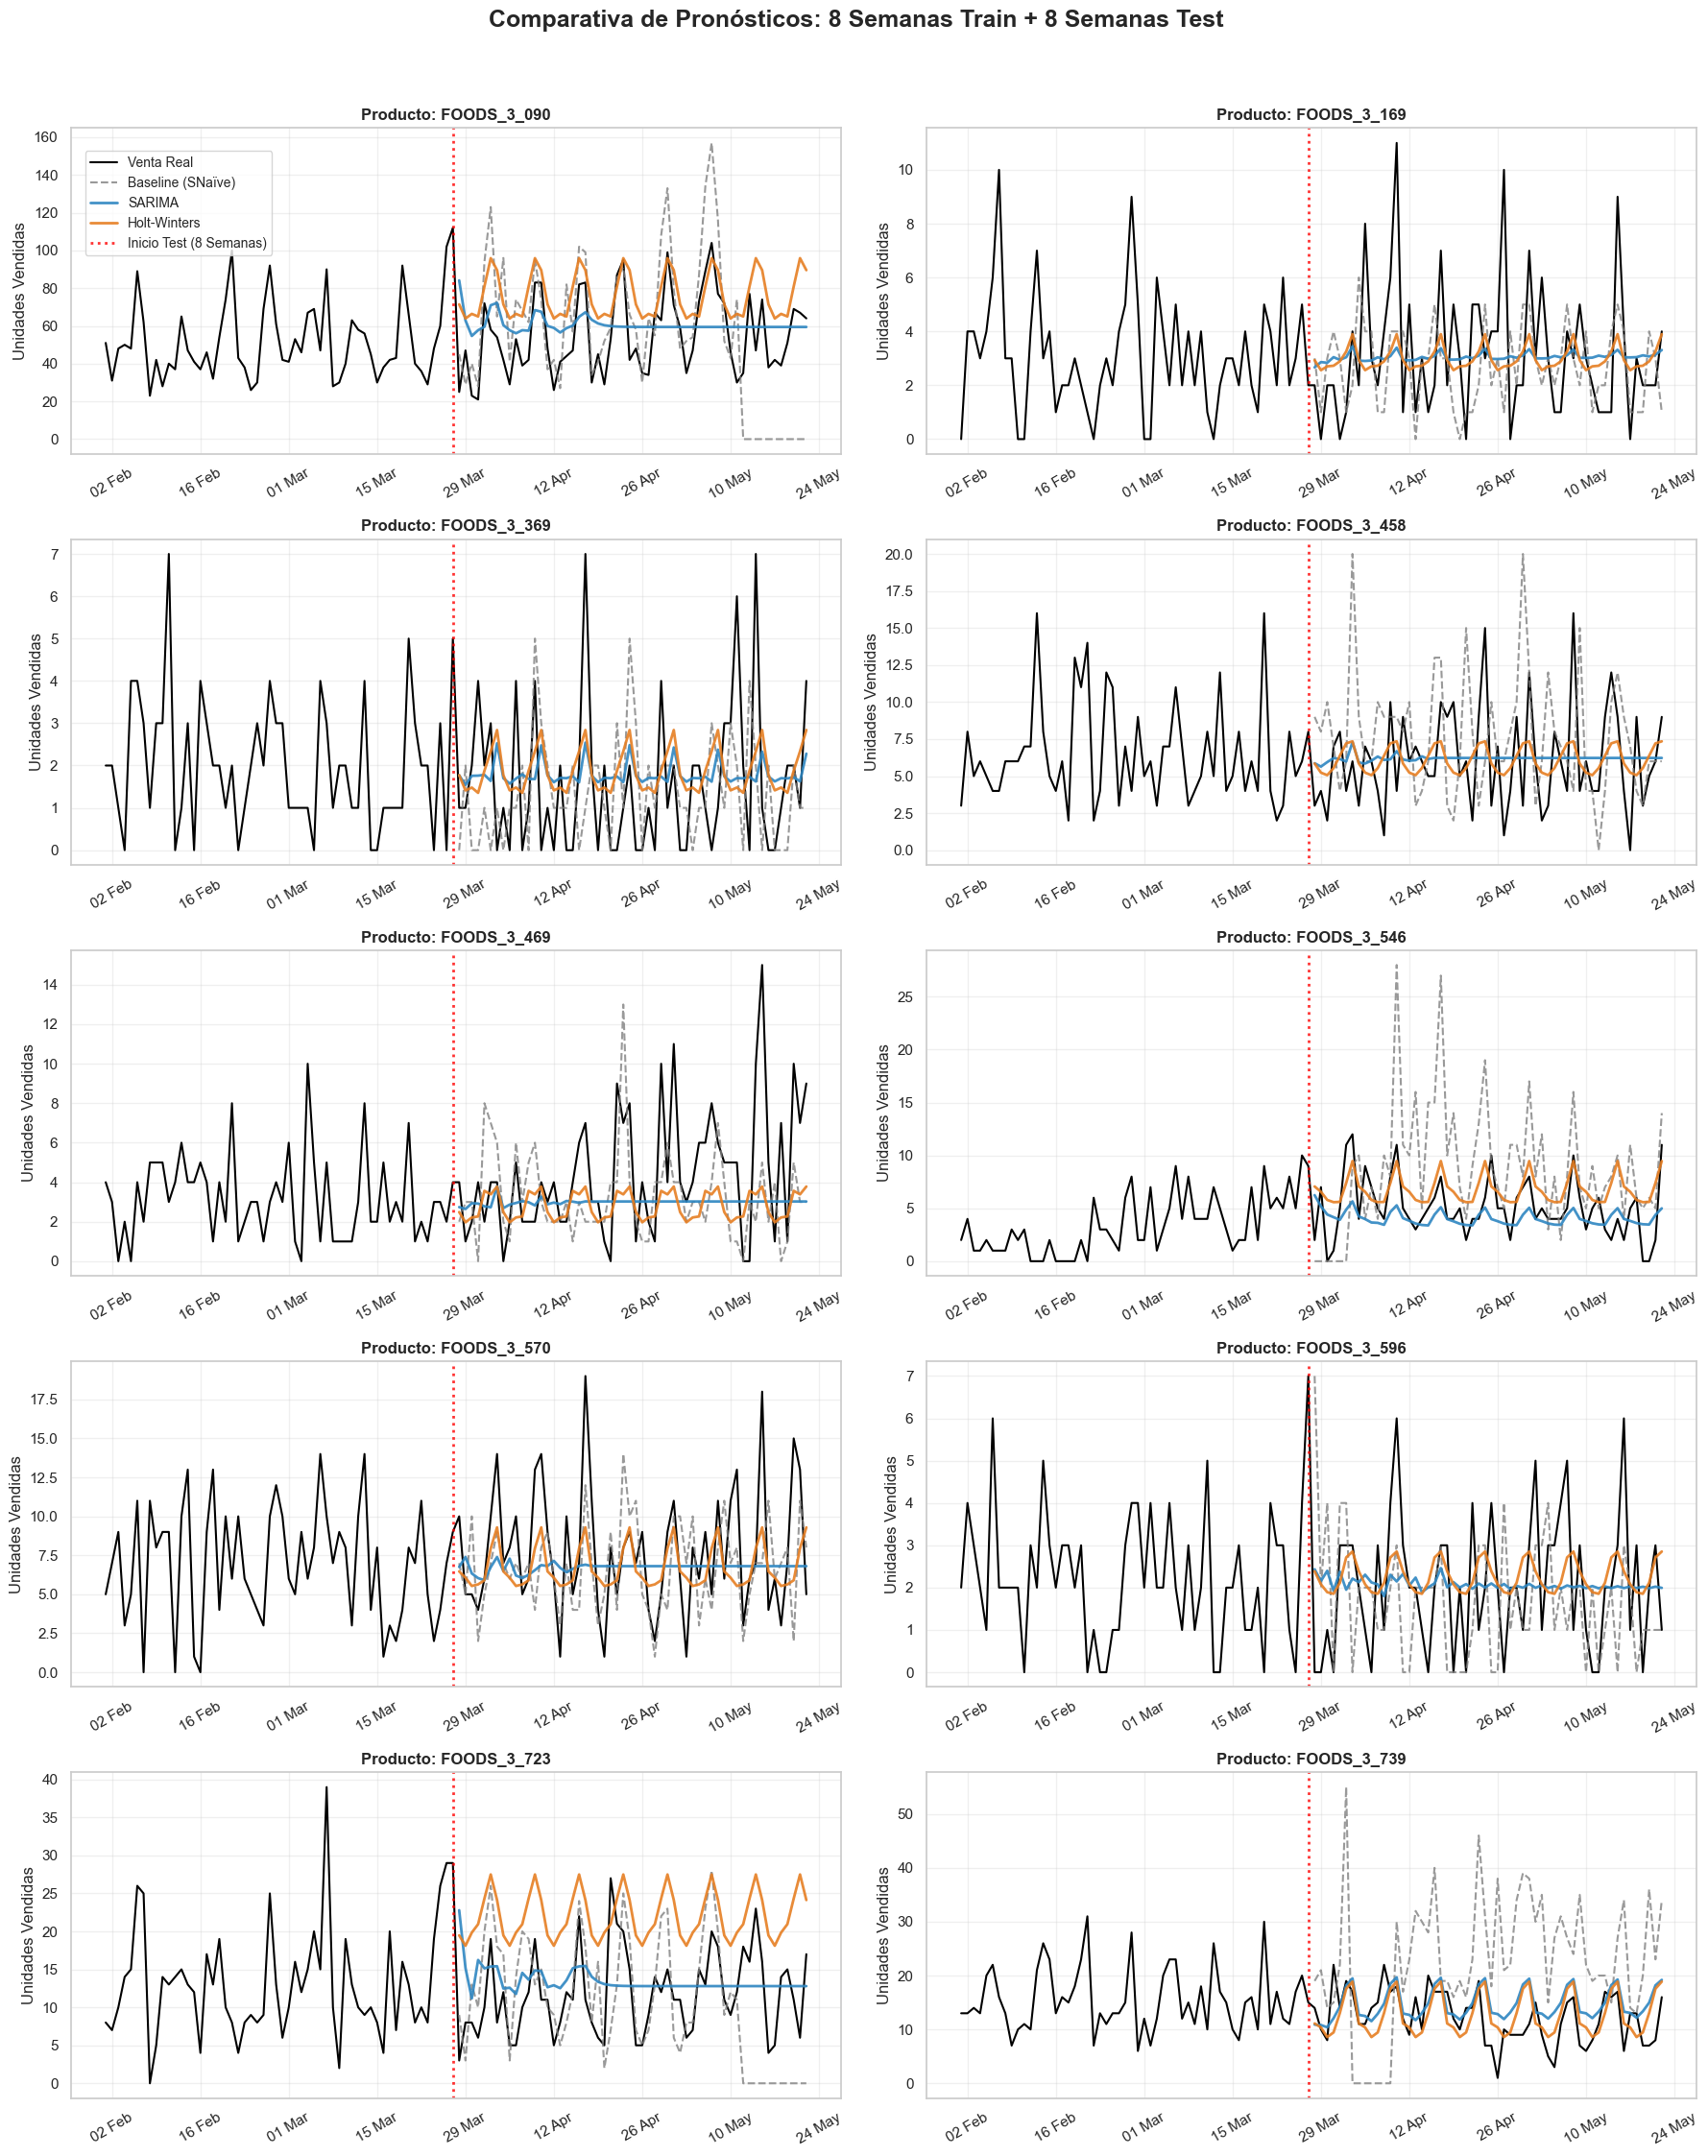

In [61]:
# 1. Aislar las últimas 8 semanas (56 días) del conjunto de Train
start_plot_date = cutoff_date - pd.Timedelta(days=56)
history_plot = train_df[train_df['date'] > start_plot_date][['item_id', 'date', 'sales']].copy()

# En el periodo histórico, no hay predicciones, así que rellenamos con NaN
history_plot['pred_snaive_anual'] = np.nan
history_plot['pred_sarima'] = np.nan
history_plot['pred_hw'] = np.nan

# 2. Aislar las columnas relevantes de nuestro DataFrame de resultados (Test)
test_plot = resultados_finales[['item_id', 'date', 'sales', 'pred_snaive_anual', 'pred_sarima', 'pred_hw']].copy()

# 3. Unir ambos periodos para tener las 16 semanas continuas
plot_df = pd.concat([history_plot, test_plot], ignore_index=True)
plot_df = plot_df.sort_values(by=['item_id', 'date'])

# 4. Crear la cuadrícula de subgráficos (5 filas x 2 columnas)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 22))
axes = axes.flatten()

productos = plot_df['item_id'].unique()

print("Generando gráficos comparativos de 16 semanas...")

for i, prod_id in enumerate(productos):
    ax = axes[i]
    
    # Filtramos los datos por producto
    df_prod = plot_df[plot_df['item_id'] == prod_id]
    
    # Línea de ventas reales (Historia + Test)
    ax.plot(df_prod['date'], df_prod['sales'], label='Venta Real', color='black', linewidth=1.5)
    
    # Líneas de pronóstico (Solo aparecerán en el periodo de Test)
    ax.plot(df_prod['date'], df_prod['pred_snaive_anual'], label='Baseline (SNaïve)', color='gray', linestyle='--', alpha=0.8)
    ax.plot(df_prod['date'], df_prod['pred_sarima'], label='SARIMA', color='#2E86C1', linewidth=2, alpha=0.9)
    ax.plot(df_prod['date'], df_prod['pred_hw'], label='Holt-Winters', color='#E67E22', linewidth=2, alpha=0.9)
    
    # Línea vertical para dividir claramente Train y Test
    ax.axvline(x=cutoff_date, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Inicio Test (8 Semanas)')
    
    # Formato y estética
    ax.set_title(f'Producto: {prod_id}', fontsize=12, weight='bold')
    ax.set_ylabel('Unidades Vendidas')
    ax.grid(True, alpha=0.3)
    
    # Ajustar las fechas del eje X para que no se superpongan
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2)) # Etiqueta cada 2 semanas
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) # Ej: 15 Oct
    ax.tick_params(axis='x', rotation=30)
    
    # Mostrar la leyenda solo en el primer gráfico para mantenerlo limpio
    if i == 0:
        ax.legend(loc='upper left', fontsize=10, bbox_to_anchor=(0.01, 0.95))

# Ajustes finales del título global
plt.suptitle('Comparativa de Pronósticos: 8 Semanas Train + 8 Semanas Test', y=1.02, fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

In [66]:
def calculate_smape(y_true, y_pred):
    """Calcula el sMAPE evitando división por cero."""
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # Si ambos son cero, el error es cero
    smape_array = np.where(denominador == 0, 0, numerador / denominador)
    return np.mean(smape_array) * 100

resultados_nuevos = []

for prod_id in resultados_finales['item_id'].unique():
    df_prod = resultados_finales[resultados_finales['item_id'] == prod_id]
    
    y_true = df_prod['sales']
    y_sarima = df_prod['pred_sarima']
    y_hw = df_prod['pred_hw']
    
    # 1. Calcular Correlación de Pearson (usamos np.corrcoef)
    # [0, 1] obtiene el valor de correlación cruzada de la matriz
    corr_sarima = np.corrcoef(y_true, y_sarima)[0, 1]
    corr_hw = np.corrcoef(y_true, y_hw)[0, 1]
    
    # 2. Calcular sMAPE
    smape_sarima = calculate_smape(y_true, y_sarima)
    smape_hw = calculate_smape(y_true, y_hw)
    
    resultados_nuevos.append({
        'item_id': prod_id,
        'Corr_SARIMA': corr_sarima,
        'Corr_HW': corr_hw,
        'sMAPE_SARIMA': smape_sarima,
        'sMAPE_HW': smape_hw
    })

df_metricas_avanzadas = pd.DataFrame(resultados_nuevos)
df_metricas_avanzadas = df_metricas_avanzadas.round(2)

In [69]:
df_metricas_avanzadas

,item_id,Corr_SARIMA,Corr_HW,sMAPE_SARIMA,sMAPE_HW
0,FOODS_3_090,0.06,0.71,35.02,39.29
1,FOODS_3_169,0.35,0.38,63.42,63.71
2,FOODS_3_369,0.14,0.21,100.06,103.22
3,FOODS_3_458,0.08,0.43,46.47,45.45
4,FOODS_3_469,0.18,0.57,68.19,66.66
5,FOODS_3_546,0.45,0.58,48.21,49.18
6,FOODS_3_570,0.15,0.57,42.42,37.62
7,FOODS_3_596,0.02,0.41,73.03,72.04
8,FOODS_3_723,-0.14,0.64,43.21,69.03
9,FOODS_3_739,0.38,0.41,33.90,31.51


## Baseline vs Sarima vs XGBoost

Generando gráficos comparativos: Baseline vs SARIMA vs XGBoost...


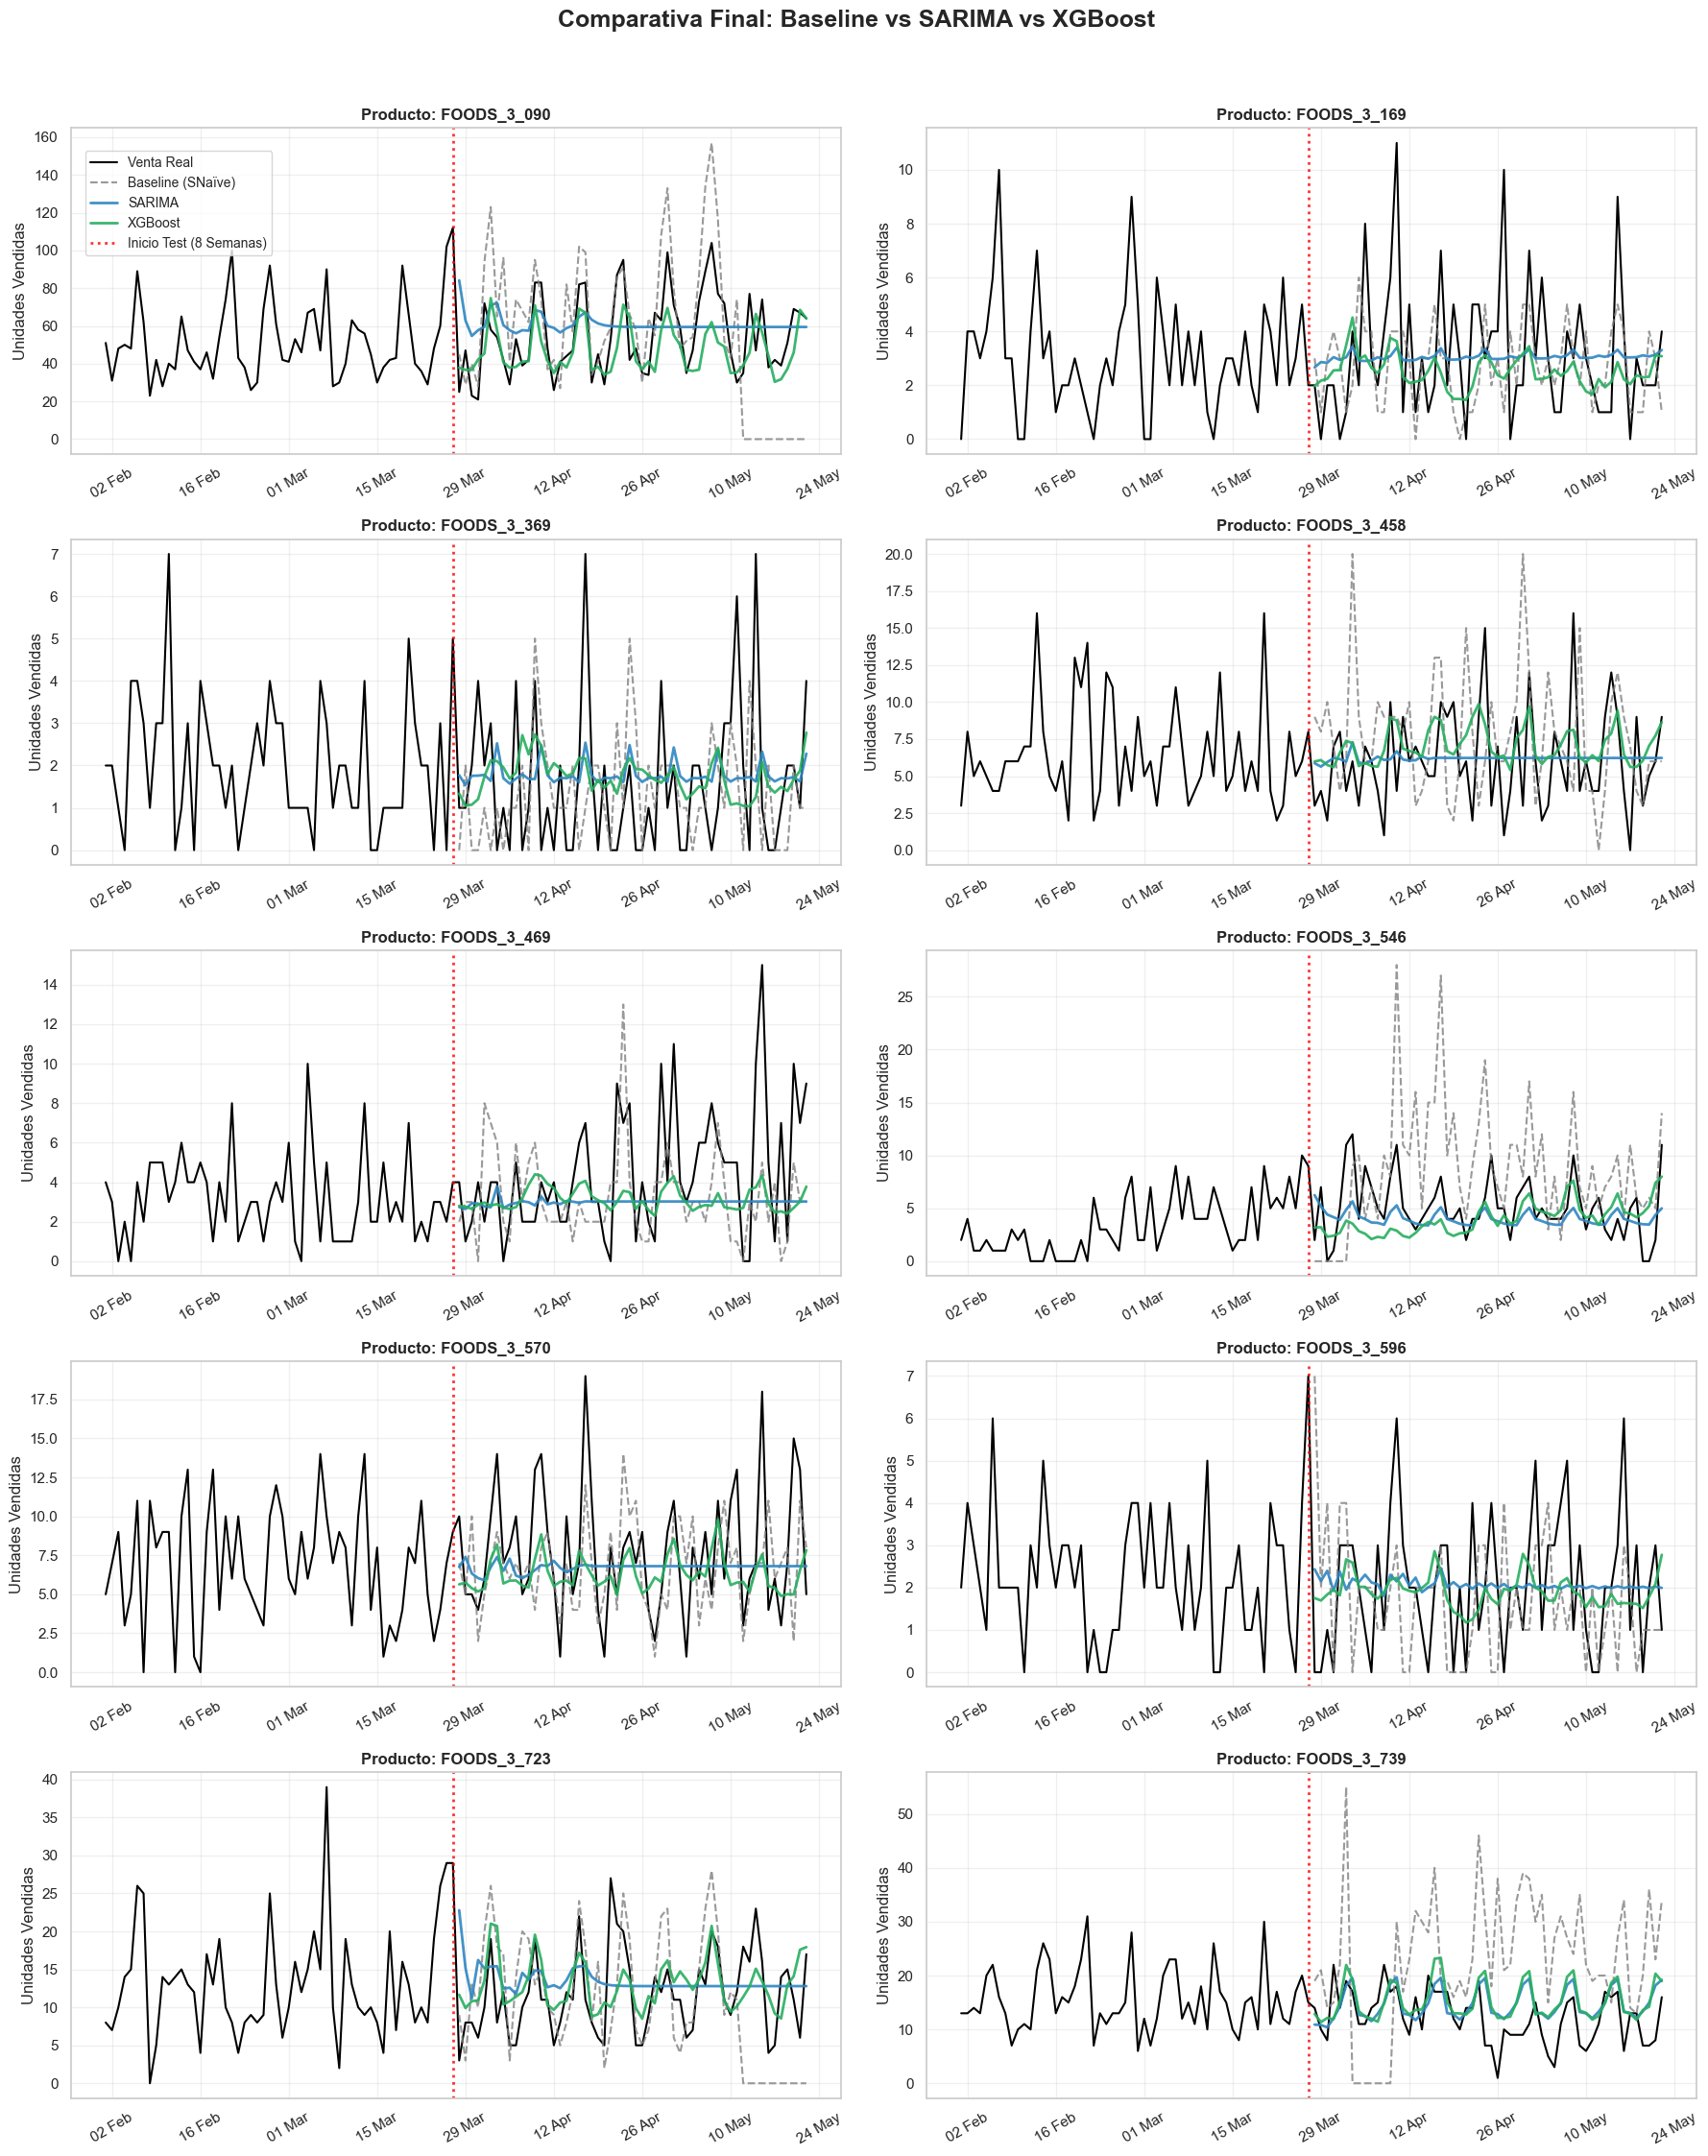

In [105]:
# 1. Aislar las últimas 8 semanas (56 días) del conjunto de Train
start_plot_date = cutoff_date - pd.Timedelta(days=56)
history_plot = train_df[train_df['date'] > start_plot_date][['item_id', 'date', 'sales']].copy()

# En el periodo histórico, no hay predicciones, así que rellenamos con NaN
history_plot['pred_snaive_anual'] = np.nan
history_plot['pred_sarima'] = np.nan
history_plot['pred_xgb_global'] = np.nan

# 2. Aislar las columnas relevantes de nuestro DataFrame de resultados (Test)
# (Asegúrate de que 'pred_xgb_global' se llame exactamente así en tu dataframe)
test_plot = resultados_finales[['item_id', 'date', 'sales', 'pred_snaive_anual', 'pred_sarima', 'pred_xgb_global']].copy()

# 3. Unir ambos periodos para tener las 16 semanas continuas
plot_df = pd.concat([history_plot, test_plot], ignore_index=True)
plot_df = plot_df.sort_values(by=['item_id', 'date'])

# 4. Crear la cuadrícula de subgráficos (5 filas x 2 columnas)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 22))
axes = axes.flatten()

productos = plot_df['item_id'].unique()

print("Generando gráficos comparativos: Baseline vs SARIMA vs XGBoost...")

for i, prod_id in enumerate(productos):
    ax = axes[i]
    
    # Filtramos los datos por producto
    df_prod = plot_df[plot_df['item_id'] == prod_id]
    
    # Línea de ventas reales (Historia + Test)
    ax.plot(df_prod['date'], df_prod['sales'], label='Venta Real', color='black', linewidth=1.5)
    
    # Líneas de pronóstico (Solo en Test)
    ax.plot(df_prod['date'], df_prod['pred_snaive_anual'], label='Baseline (SNaïve)', color='gray', linestyle='--', alpha=0.8)
    ax.plot(df_prod['date'], df_prod['pred_sarima'], label='SARIMA', color='#2E86C1', linewidth=2, alpha=0.9) # Azul
    ax.plot(df_prod['date'], df_prod['pred_xgb_global'], label='XGBoost', color='#27AE60', linewidth=2, alpha=0.9) # Verde
    
    # Línea vertical para dividir claramente Train y Test
    ax.axvline(x=cutoff_date, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Inicio Test (8 Semanas)')
    
    # Formato y estética
    ax.set_title(f'Producto: {prod_id}', fontsize=12, weight='bold')
    ax.set_ylabel('Unidades Vendidas')
    ax.grid(True, alpha=0.3)
    
    # Ajustar las fechas del eje X para lectura fácil
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
    ax.tick_params(axis='x', rotation=30)
    
    # Mostrar la leyenda solo en el primer gráfico
    if i == 0:
        ax.legend(loc='upper left', fontsize=10, bbox_to_anchor=(0.01, 0.95))

# Ajustes finales del título global
plt.suptitle('Comparativa Final: Baseline vs SARIMA vs XGBoost', y=1.02, fontsize=18, weight='bold')
plt.tight_layout()
plt.show()